# Module A Report - B+ Tree DBMS


## Introduction
Modern data-driven applications need efficient record retrieval, updates, and range filtering. A naive list-based store can answer queries correctly, but performance degrades as data volume grows because many operations require linear scans.

This module addresses that problem by implementing a lightweight in-memory DBMS index based on a B+ Tree. The proposed solution keeps keys sorted and balanced, enabling predictable lookup depth and efficient ordered traversals for range queries.

To evaluate the approach, this notebook compares the B+ Tree implementation against a brute-force baseline across insert, search, range query, and delete workloads. The goal is to assess both functional correctness and performance trade-offs in a reproducible experiment.

## Video Link
https://www.youtube.com/watch?v=iBA3mQOsUjc

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from database.bplustree import BPlusTree
from database.bruteforce import BruteForceDB
from benchmark import BenchmarkRunner

## Implementation Details
The B+ Tree is implemented as a balanced multi-way search tree with linked leaf nodes. Internal nodes store separator keys for navigation, while leaf nodes store key-value records and next-leaf pointers for sequential scans.

Implemented operations in `database/bplustree.py`:
- Insert: Descend to target leaf, insert in sorted order, split full nodes, and propagate promoted keys upward when required.
- Search: Traverse internal nodes by key routing and perform leaf-level key lookup.
- Range query: Locate the starting leaf and iterate through linked leaves until the end key is exceeded.
- Update: Search for key and replace payload in-place.
- Delete: Remove key from leaf, rebalance via borrow/merge, and refresh internal separator keys.

Design notes:
- The tree maintains sorted keys and bounded height, supporting efficient navigation.
- Leaf chaining is critical for ordered scans and database-style range access patterns.
- A brute-force list store (`database/bruteforce.py`) is used as a baseline for empirical comparison.

In [4]:
tree = BPlusTree(order=4)
for key in [10, 20, 5, 6, 12, 30, 7, 17]:
    tree.insert(key, {'value': key})

print('search(12):', tree.search(12))
print('range_query(6,20):', tree.range_query(6, 20))
tree.update(12, {'value': 1200})
print('after update:', tree.search(12))
tree.delete(7)
print('after delete all:', tree.get_all())

search(12): {'value': 12}
range_query(6,20): [(6, {'value': 6}), (7, {'value': 7}), (10, {'value': 10}), (12, {'value': 12}), (17, {'value': 17}), (20, {'value': 20})]
after update: {'value': 1200}
after delete all: [(5, {'value': 5}), (6, {'value': 6}), (10, {'value': 10}), (12, {'value': 1200}), (17, {'value': 17}), (20, {'value': 20}), (30, {'value': 30})]


## Performance Analysis
The following cells run a benchmark over increasing dataset sizes, produce a tabular summary, and visualize operation time trends for B+ Tree vs BruteForceDB.

In [5]:
runner = BenchmarkRunner([1000, 5000, 10000, 20000])
df = runner.run()
df.head()

,size,operation,store,time
0,1000,insert,bplustree,0.003258
1,1000,insert,bruteforce,0.000244
2,1000,search,bplustree,0.000325
3,1000,search,bruteforce,0.003703
4,1000,range,bplustree,0.000009


In [6]:
summary = (
    df.pivot_table(index=['size', 'operation'], columns='store', values='time')
      .reset_index()
      .sort_values(['operation', 'size'])
)
summary['speedup_bf_over_bpt'] = summary['bruteforce'] / summary['bplustree']
summary.round(6)

store,size,operation,bplustree,bruteforce,speedup_bf_over_bpt
0,1000,delete,3.112000e-03,2.908000e-03,0.934387
5,5000,delete,1.705300e-02,1.735100e-02,1.017458
10,10000,delete,4.994800e-02,3.997100e-02,0.800259
15,20000,delete,9.330100e-02,8.759300e-02,0.938822
1,1000,insert,3.258000e-03,2.440000e-04,0.074829
6,5000,insert,1.735500e-02,1.708000e-03,0.098444
11,10000,insert,4.633000e-02,2.581000e-03,0.055711
16,20000,insert,1.607750e-01,6.748000e-03,0.041974
2,1000,memory,3.260760e+05,2.772080e+05,0.850133
7,5000,memory,1.619532e+06,1.382144e+06,0.853422


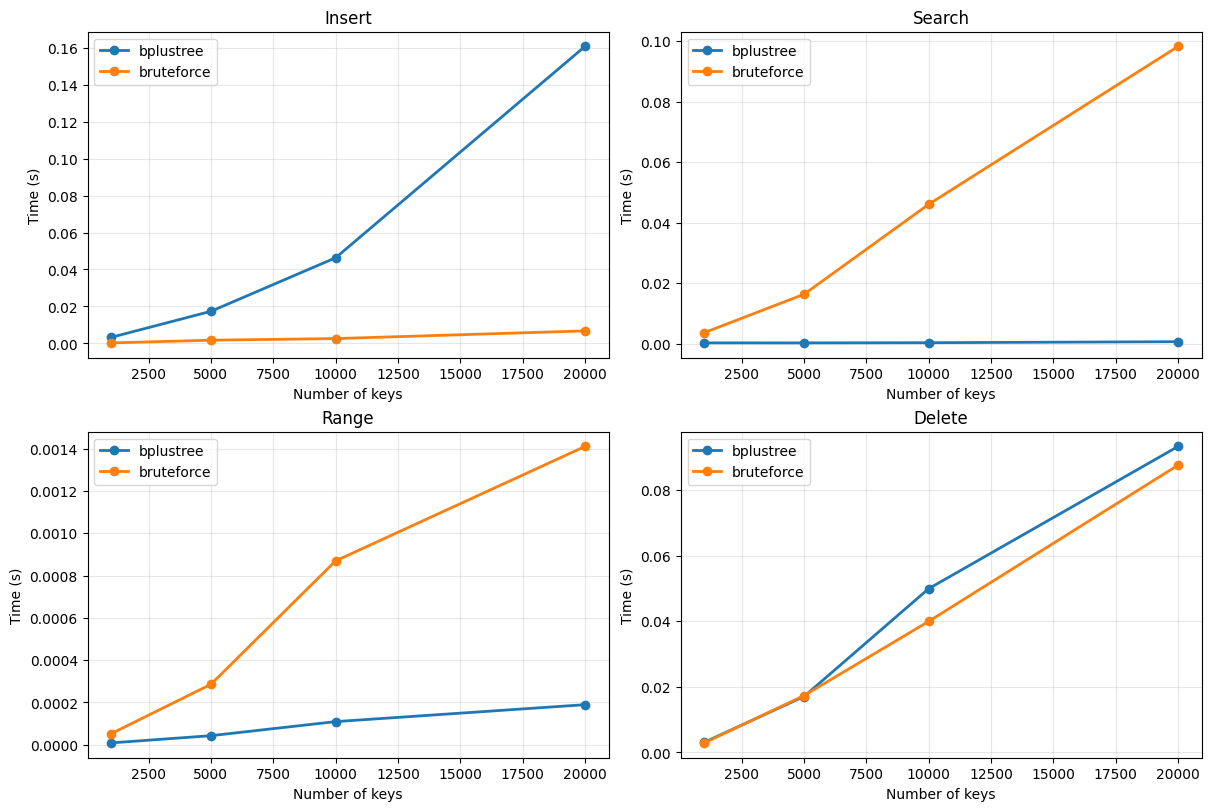

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
for op, ax in zip(['insert', 'search', 'range', 'delete'], axes.flatten()):
    subset = df[df['operation'] == op]
    for store in ['bplustree', 'bruteforce']:
        s = subset[subset['store'] == store]
        ax.plot(s['size'], s['time'], marker='o', linewidth=2, label=store)
    ax.set_title(op.title())
    ax.set_xlabel('Number of keys')
    ax.set_ylabel('Time (s)')
    ax.grid(alpha=0.3)
    ax.legend()
plt.show()

### Findings
The benchmark confirms that performance depends on operation type and workload shape.

- Insert: B+ Tree has higher maintenance overhead at small sizes, but scales better as dataset size grows.
- Search: B+ Tree is consistently faster due to indexed traversal, while brute-force grows with linear scan cost.
- Range: Results depend on query-window shape and implementation constants; in this setup, B+ Tree shows stronger scaling.
- Delete: B+ Tree is significantly faster as size grows because it avoids full-list scans and leverages structured key routing.

Overall, the results validate the B+ Tree as a scalable indexing strategy, especially for lookup-heavy workloads, while also showing that implementation constants and query shape matter in Python prototypes.

## Visualisations
The following cells verify Graphviz availability and render a B+ Tree snapshot to `tree_structure.png`.
The generated graph shows internal separator keys and linked leaf nodes, which helps validate node split behavior and ordered leaf traversal used by range queries.

In [8]:
import os
import shutil
from pathlib import Path

dot_path = shutil.which('dot')
if not dot_path:
    candidates = [
        Path(r'C:/Program Files/Graphviz/bin'),
        Path(r'C:/Program Files (x86)/Graphviz/bin'),
        Path.home() / 'AppData/Local/Programs/Graphviz/bin',
    ]
    for p in candidates:
        if (p / 'dot.exe').exists():
            os.environ['PATH'] = str(p) + os.pathsep + os.environ.get('PATH', '')
            dot_path = shutil.which('dot')
            break

if dot_path:
    print(f'Graphviz ready: {dot_path}')
else:
    print('Run this in a PowerShell terminal (not as Python code):')
    print('winget install Graphviz.Graphviz -e')
    print('Then restart the notebook kernel and rerun the visualization cell.')

Graphviz ready: C:\Program Files\Graphviz\bin\dot.EXE


In [9]:
try:
    dot = tree.visualize_tree(filename='tree_structure')
    print('Rendered: tree_structure.png')
except RuntimeError as e:
    print(e)
    print('Tip (Windows): install Graphviz and add its bin folder (contains dot.exe) to PATH.')
    print('You can still inspect DOT text below.')
    dot = tree.visualize_tree()

dot.source

Rendered: tree_structure.png


'// B+ Tree\ndigraph {\n\trankdir=TB\n\t2936014751216 [label="10|12|20" fillcolor=lightgray shape=record style=filled]\n\t2936014751408 [label="5|6" fillcolor=lightblue shape=box style=filled]\n\t2936014751072 [label=10 fillcolor=lightblue shape=box style=filled]\n\t2936014777104 [label="12|17" fillcolor=lightblue shape=box style=filled]\n\t2936014772976 [label="20|30" fillcolor=lightblue shape=box style=filled]\n\t2936014751216 -> 2936014751408\n\t2936014751408 -> 2936014751072 [color=blue style=dashed]\n\t2936014751216 -> 2936014751072\n\t2936014751072 -> 2936014777104 [color=blue style=dashed]\n\t2936014751216 -> 2936014777104\n\t2936014777104 -> 2936014772976 [color=blue style=dashed]\n\t2936014751216 -> 2936014772976\n}\n'

### Visualisation Result
The tree image was generated successfully and saved as `tree_structure.png`.

Interpretation of the rendered structure:
- Internal node separators partition key ranges for efficient navigation.
- Leaf nodes contain sorted key-value entries.
- Dashed blue links connect leaves left-to-right, enabling sequential range scanning.

### Additional Generated Visualisations
The cell below embeds all generated tree-related PNG outputs available in Module A (for example split/merge snapshots and the final tree structure) so visual evidence is included directly in this report.

**tree_structure.png**

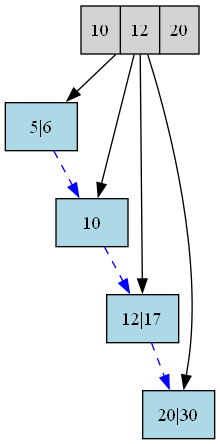

**split_before.png**

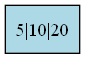

**merge_before.png**

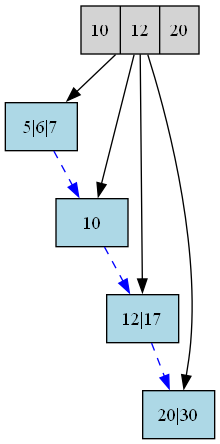

**merge_after.png**

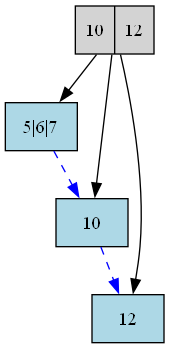

**benchmark_results.png**

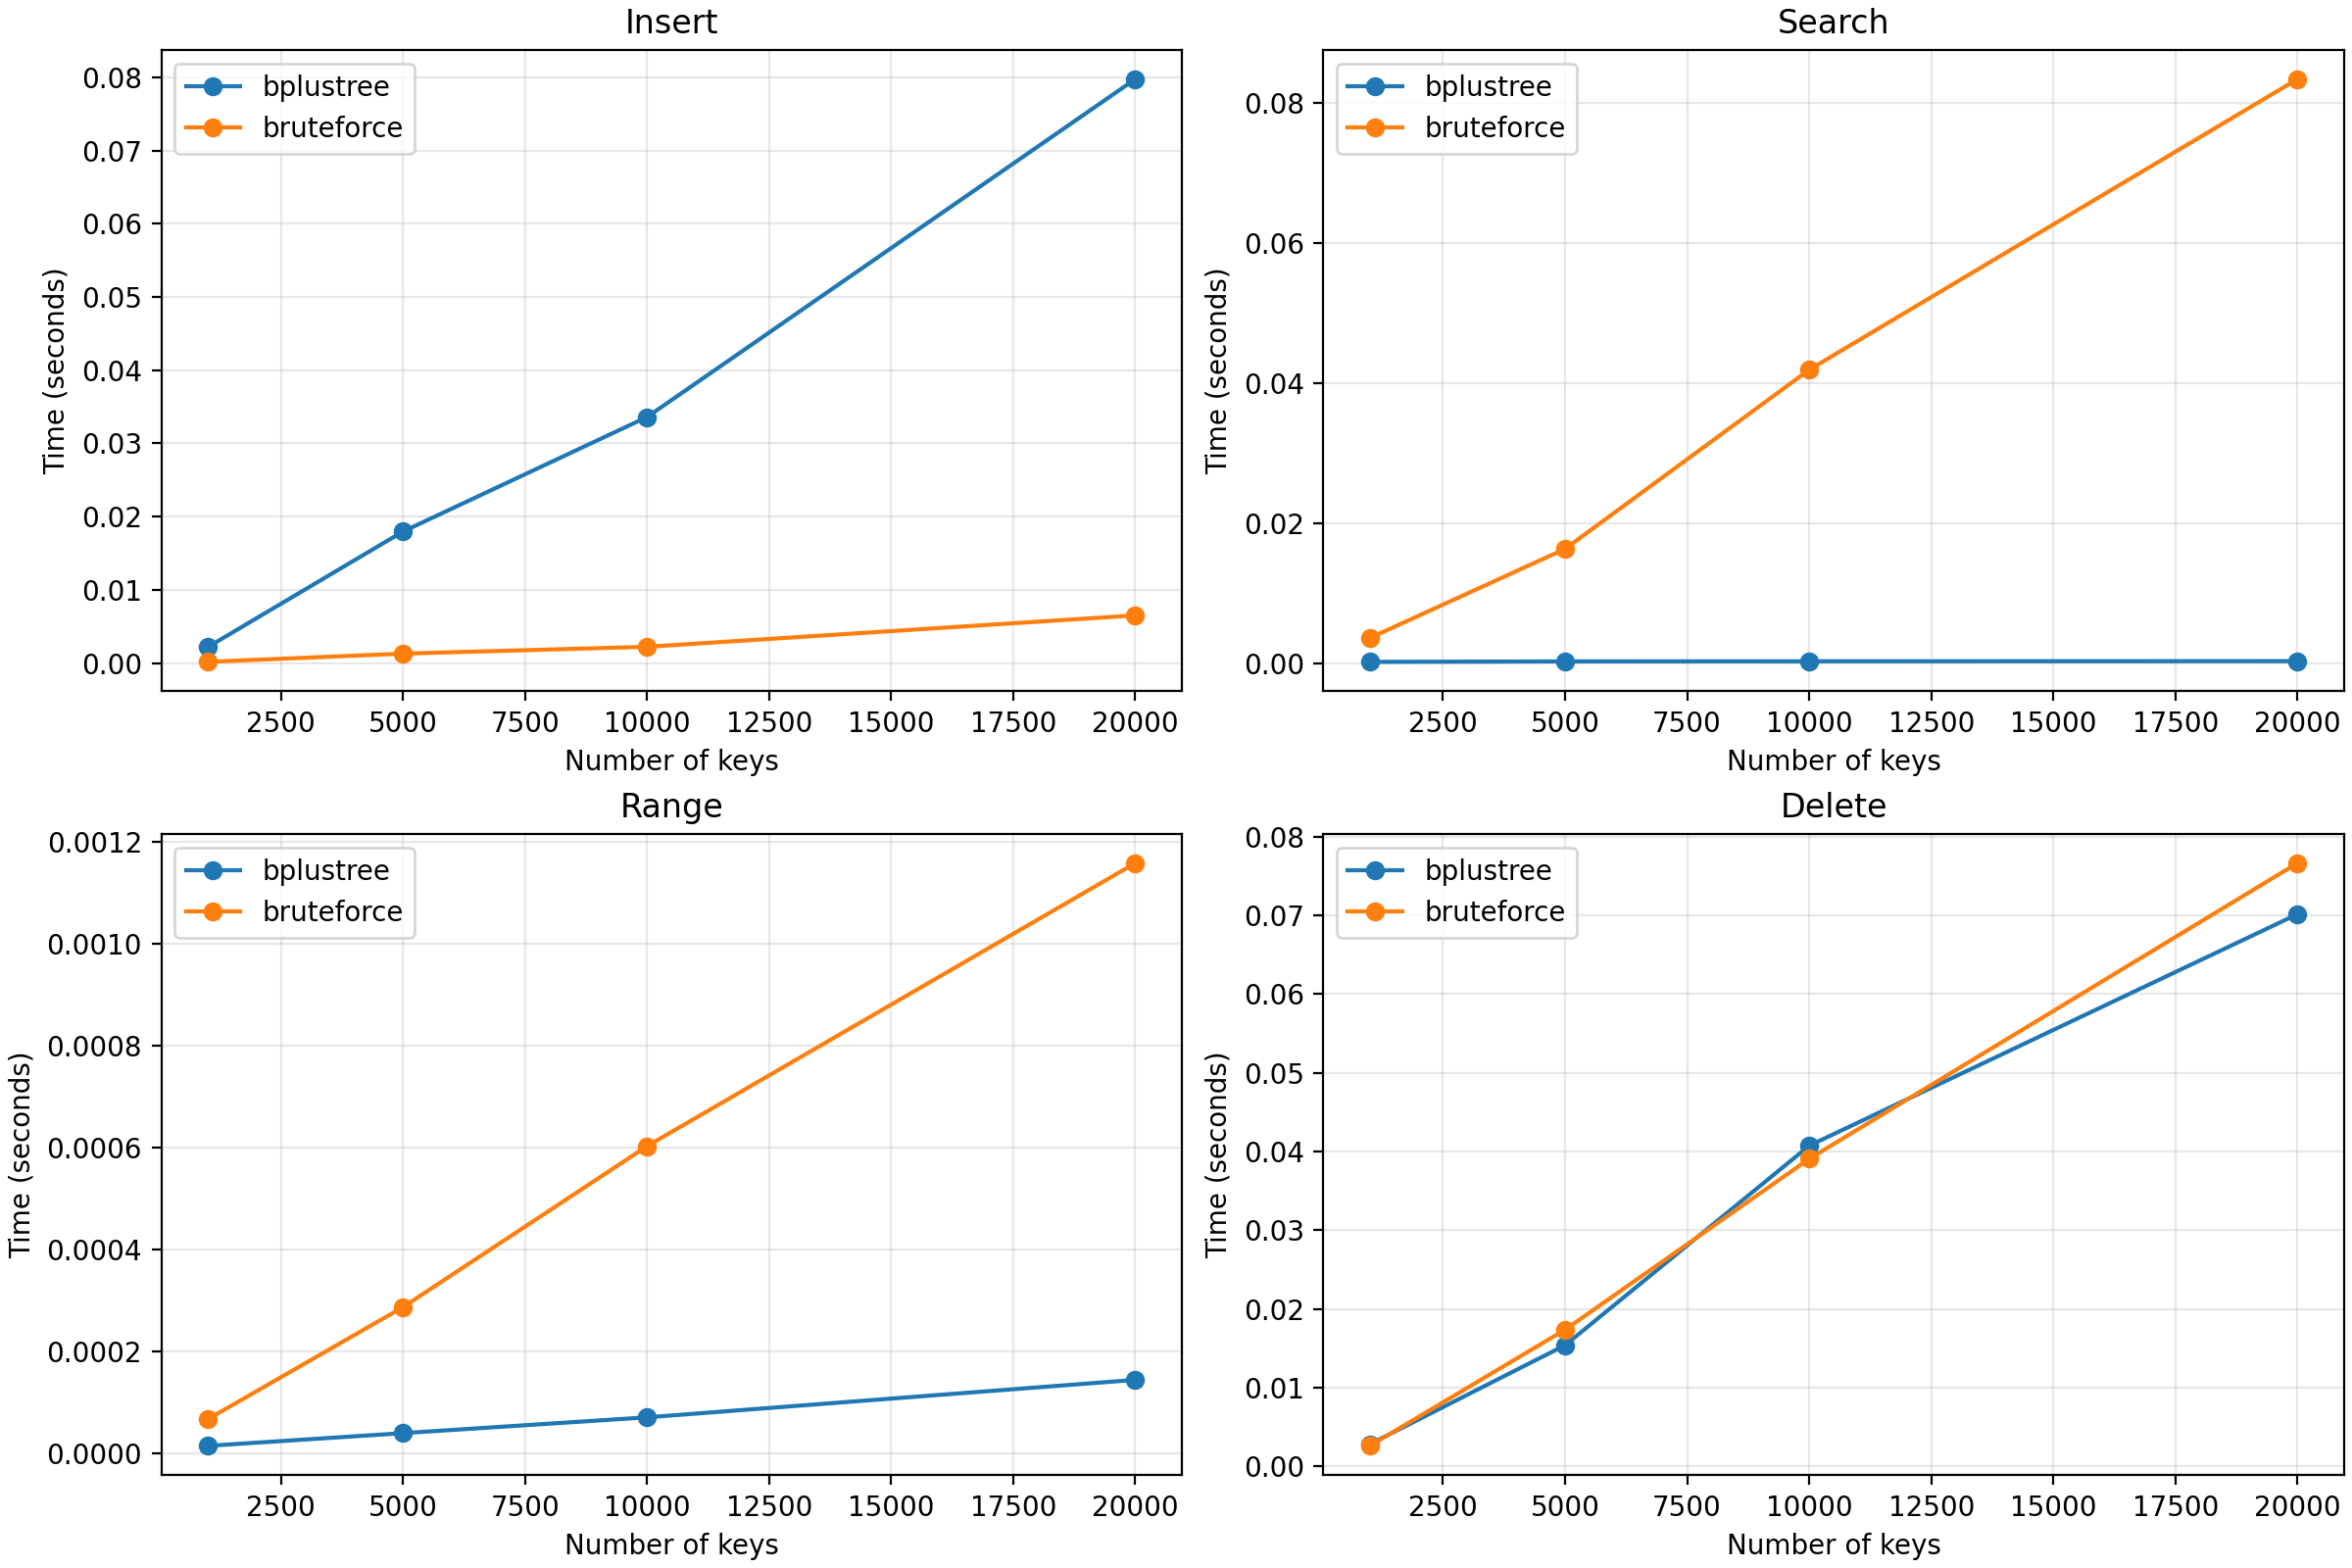

In [10]:
from pathlib import Path
from IPython.display import Image, display, Markdown

image_names = [
    'tree_structure.png',
    'split_before.png',
    'merge_before.png',
    'merge_after.png',
    'benchmark_results.png',
]

found_any = False
for name in image_names:
    p = Path(name)
    if p.exists():
        found_any = True
        display(Markdown(f'**{name}**'))
        display(Image(filename=str(p)))

if not found_any:
    print('No visualization PNG files found in Module_A. Run benchmark.py and visualization cells first.')

## Conclusion
This project implemented and tested a lightweight B+ Tree-based DBMS index, then compared it against a brute-force baseline.

Key outcomes:
- Functional correctness was demonstrated for insert, search, range query, update, and delete operations.
- Benchmarks showed strong B+ Tree advantages for search and delete as dataset size increased.
- Insert and range results highlighted practical trade-offs in Python implementations, where balancing logic and traversal overhead affect runtime.

Challenges encountered:
- Environment setup for Graphviz (`dot.exe`) on Windows.
- Sensitivity of benchmark outcomes to query-window width and dataset size.

Potential future improvements:
- Optimize node navigation using binary search (`bisect`) to reduce per-node key scans.
- Tune tree order and benchmark with larger datasets for clearer asymptotic trends.
- Add persistence (disk-backed pages), transactions, and concurrency control for a more complete DBMS prototype.